In [ ]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import nltk
import spacy

from nltk import ngrams
from nltk.corpus import stopwords, words
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

from transformers import pipeline

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("words")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [ ]:
!pip install -q spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
#NLP model
#Using the spaCy language model
nlp = spacy.load("en_core_web_sm")

#Using the HuggingFace Zero-shot Classifier
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0
)

#Using the English vocabulary
english_vocab = set(words.words())

#English stopwords
common_words = set(stopwords.words("english"))

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [ ]:
#loading the data

SCRIPT_PATH = "blackpanther.txt"
#enter the name of script

with open(SCRIPT_PATH, "r", encoding="utf-8") as file:
    script = file.read()

print(f"Characters loaded: {len(script):,}")

Characters loaded: 141,643


In [ ]:
#text preprocessing

clean_text = script.lower() #lowercase

clean_text = re.sub(r"[^a-z\s]", " ", clean_text) # Remove punctuation

tokens = word_tokenize(clean_text)#tokenisation

print("Total Tokens:", len(tokens))
print("Sample Tokens:")
print(tokens[:20])

Total Tokens: 24908
Sample Tokens:
['black', 'panther', 'adapted', 'screenplay', 'written', 'by', 'ryan', 'coogler', 'joe', 'robert', 'cole', 'ext', 'deep', 'space', 'a', 'dark', 'screen', 'is', 'lit', 'up']


In [ ]:
#Word Frequency Analysis
rare_words = [
    word
    for word in tokens
    if word not in common_words
]

frequency = Counter(rare_words)

print("Most Common Non-Stopwords\n")

for word, count in frequency.most_common(20):
    print(f"{word:<20} {count}")

Most Common Non-Stopwords

challa               426
nakia                219
killmonger           202
shuri                194
klaue                177
ross                 173
okoye                167
cont                 117
night                109
panther              105
int                  105
back                 99
ext                  94
day                  93
looks                76
baku                 76
w                    73
zuri                 69
kabi                 68
n                    62


In [ ]:
#TF - IDF Analysis
vectorizer = TfidfVectorizer(stop_words="english")

tfidf_matrix = vectorizer.fit_transform([clean_text])

feature_names = vectorizer.get_feature_names_out()

scores = tfidf_matrix.toarray()[0]

tfidf_scores = sorted(
    zip(feature_names, scores),
    key=lambda x: x[1],
    reverse=True
)

print("Top TF-IDF Terms\n")

for word, score in tfidf_scores[:20]:
    print(f"{word:<20} {score:.4f}")

Top TF-IDF Terms

challa               0.5422
nakia                0.2788
killmonger           0.2571
shuri                0.2469
klaue                0.2253
ross                 0.2202
okoye                0.2126
cont                 0.1489
night                0.1387
int                  0.1337
panther              0.1337
ext                  0.1197
day                  0.1184
baku                 0.0967
looks                0.0967
zuri                 0.0878
kabi                 0.0866
ramonda              0.0789
jobu                 0.0764
wakanda              0.0751


In [ ]:
#Named Entity Recognition(NER)

doc = nlp(clean_text) #clean text with spaCy

# Extract all named entities
entities = [(ent.text, ent.label_) for ent in doc.ents]

print("Sample Named Entities:\n")
print(entities[:20])

#Frequency of Entities
entity_texts = [ent.text for ent in doc.ents]

entity_frequency = Counter(entity_texts)

print("Most Common Entities:\n")

for entity, count in entity_frequency.most_common(20):
    print(f"{entity:<25} {count}")

#Script Character Analysis
people = [
    ent.text
    for ent in doc.ents
    if ent.label_ == "PERSON"
]

print("Top Characters:\n")

for person, count in Counter(people).most_common(10):
    print(f"{person:<20} {count}")


Sample Named Entities:

[('joe robert cole \next  deep', 'PERSON'), ('millions', 'CARDINAL'), ('africa', 'LOC'), ('africa', 'LOC'), ('five', 'CARDINAL'), ('five', 'CARDINAL'), ('first', 'ORDINAL'), ('four', 'CARDINAL'), ('wakanda  s', 'ORG'), ('cont d  \n', 'PERSON'), ('oakland', 'GPE'), ('night', 'TIME'), ('african', 'NORP'), ('african', 'NORP'), ('american', 'NORP'), ('james cocks', 'PERSON'), ('two', 'CARDINAL'), ('two', 'CARDINAL'), ('azzuri', 'NORP'), ('dora milaje', 'PERSON')]
Most Common Entities:

shuri                     143
night                     56
two                       36
one                       31
day                       27
south korea               26
cont d  
                 25
shuri s                   21
first                     19
cia                       17
korean                    15
don                       13
klaue s  runner           13
oakland                   11
cont                      11
second                    11
linda                   

In [ ]:
#Script Place Analysis
places = [
    ent.text
    for ent in doc.ents
    if ent.label_ in ("GPE", "LOC")
]

print("Top Places (spaCy):\n")

for place, count in Counter(places).most_common(10):
    print(f"{place:<20} {count}")

#Location Heuristic
def is_location_like(entity, document):
    """
    Identify fictional or mythological locations using
    contextual keywords surrounding the entity.
    """

    keywords = [
        "kingdom",
        "city",
        "village",
        "land",
        "forest",
        "mountain",
        "river",
        "realm",
        "nation",
        "country",
        "island",
        "desert",
        "valley",
        "palace"
    ]

    window = 5

    for sentence in document.sents:

        if entity in sentence.text:

            tokens = [token.text for token in sentence]

            indices = [
                i
                for i, token in enumerate(tokens)
                if token == entity
            ]

            for index in indices:

                context = tokens[
                    max(0, index-window):
                    min(len(tokens), index+window)
                ]

                if any(word in context for word in keywords):
                    return True

    return False

#Heuristic Location Detection
refined_places = []

for ent in doc.ents:

    if ent.label_ in ("GPE", "LOC"):

        refined_places.append(ent.text)

    elif is_location_like(ent.text, doc):

        refined_places.append(ent.text)

print("Top Places (Refined):\n")

for place, count in Counter(refined_places).most_common(15):
    print(f"{place:<20} {count}")

Top Places (spaCy):

shuri                139
south korea          26
oakland              11
cont                 11
baku                 7
wakanda              5
london               4
africa               3
golden city          3
uk                   3
Top Places (Refined):

shuri                139
night                56
two                  36
day                  27
south korea          26
oakland              11
cont                 11
second               11
morning              9
wakanda              8
third                7
baku                 7
nakia                5
london               4
africa               3


In [ ]:
#Dependecy Parsing
dependency_triples = []

for sentence in doc.sents:

    for token in sentence:

        if token.dep_ == "nsubj" and token.head.pos_ == "VERB":

            subject = token.text
            verb = token.head.text

            objects = [
                child.text
                for child in token.head.children
                if child.dep_ in ("dobj", "attr", "pobj")
            ]

            dependency_triples.append(
                (subject, verb, objects)
            )

print("Sample Subject–Verb–Object Relationships:\n")

for triple in dependency_triples[:15]:
    print(triple)

Sample Subject–Verb–Object Relationships:

('panther', 'adapted', ['screenplay'])
('father', 'tell', ['father'])
('meteorite', 'struck', [])
('substance', 'struck', [])
('continent', 'affecting', ['life'])
('meteorite', 'hits', ['africa'])
('we', 'see', ['life'])
('time', 'came', [])
('tribes', 'settled', [])
('tribes', 'lived', [])
('shaman', 'received', ['vision'])
('who', 'led', ['him'])
('that', 'granted', ['speed'])
('we', 'see', [])
('them', 'unite', [])


First 40 Classified Sentences

1. [MYTH] 0.767
black panther 
adapted screenplay 
written by ryan coogler   joe robert cole 
ext  deep space 
a dark screen is lit up by twinkling stars   
son 
baba  
father 
yes  my son  
son 
tell me a story  
father 
which one  
son 
the story of home   
a meteorite drifts into frame   heading towards tiny earth off 
in the distance  
father 
millions of years ago   a meteorite 
made of vibranium  the strongest 
substance in the universe struck 
the continent of africa affecting 
the plant life around it  
the meteorite hits africa and we see plant life and animals 
affected by vibranium  
father  cont d  
and when the time of man came   five 
tribes settled on it and called it 
wakanda  the tribes lived in 
constant war with each other until 
a warrior shaman received a vision 
from the panther goddess bast who 
led him to the heart shaped herb  a 
plant that granted him super human 
strength   speed  and instincts   
a visual representation of the 

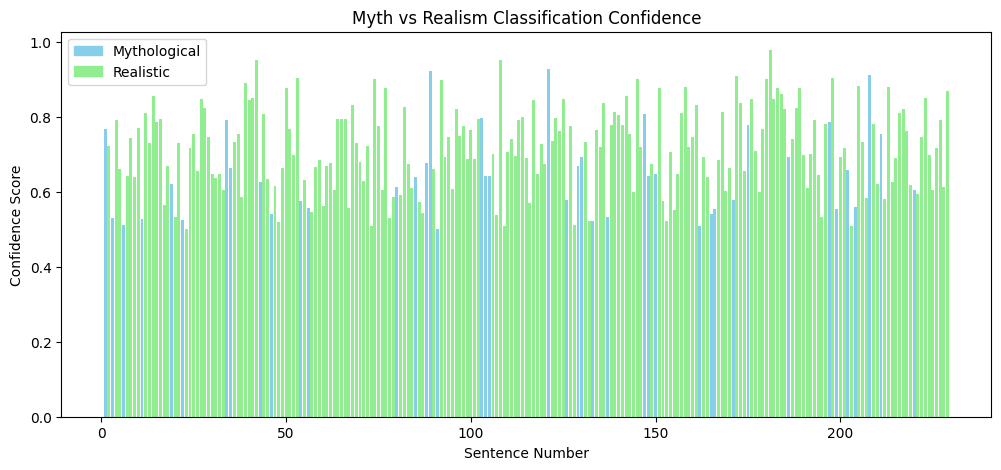

In [ ]:
#Myth vs Realism Classification
candidate_labels = [
    "mythological",
    "realistic"
]

classified_sentences = []

sentences = [
    sentence.text.strip()
    for sentence in doc.sents
]

for sentence in sentences:

    result = classifier(
        sentence,
        candidate_labels=candidate_labels
    )

    label = (
        "myth"
        if result["labels"][0] == "mythological"
        else "realism"
    )

    confidence = result["scores"][0]

    classified_sentences.append(
        (
            sentence,
            label,
            confidence
        )
    )

#Classification Results
print("First 40 Classified Sentences\n")

for i, (sentence, label, confidence) in enumerate(classified_sentences[:40], start=1):

    print(
        f"{i}. [{label.upper()}] "
        f"{confidence:.3f}"
    )

    print(sentence)

    print("-" * 80)

#Classification Confidence
sentence_numbers = list(
    range(
        1,
        len(classified_sentences) + 1
    )
)

confidence_scores = [
    score
    for _, _, score in classified_sentences
]

bar_colours = [
    "skyblue"
    if label == "myth"
    else "lightgreen"
    for _, label, _ in classified_sentences
]

plt.figure(figsize=(12,5))

plt.bar(
    sentence_numbers,
    confidence_scores,
    color=bar_colours
)

plt.xlabel("Sentence Number")
plt.ylabel("Confidence Score")
plt.title("Myth vs Realism Classification Confidence")

plt.legend(
    handles=[
        plt.Rectangle((0,0),1,1,color="skyblue"),
        plt.Rectangle((0,0),1,1,color="lightgreen")
    ],
    labels=[
        "Mythological",
        "Realistic"
    ]
)

plt.show()

In [ ]:
#Sentence splitting by classification
myth_sentences = [
    sentence
    for sentence, label, _ in classified_sentences
    if label == "myth"
]

realism_sentences = [
    sentence
    for sentence, label, _ in classified_sentences
    if label == "realism"
]

print(f"Mythological Sentences : {len(myth_sentences)}")
print(f"Realistic Sentences    : {len(realism_sentences)}")

Mythological Sentences : 42
Realistic Sentences    : 187


In [ ]:
#Dependency relationships
myth_dependencies = []
realism_dependencies = []

for sentence, label, _ in classified_sentences:

    sentence_doc = nlp(sentence)

    for token in sentence_doc:

        if token.dep_ == "nsubj" and token.head.pos_ == "VERB":

            subject = token.text

            verb = token.head.text

            objects = [
                child.text
                for child in token.head.children
                if child.dep_ in ("dobj", "attr", "pobj")
            ]

            relationship = (
                subject,
                verb,
                objects
            )

            if label == "myth":
                myth_dependencies.append(relationship)
            else:
                realism_dependencies.append(relationship)

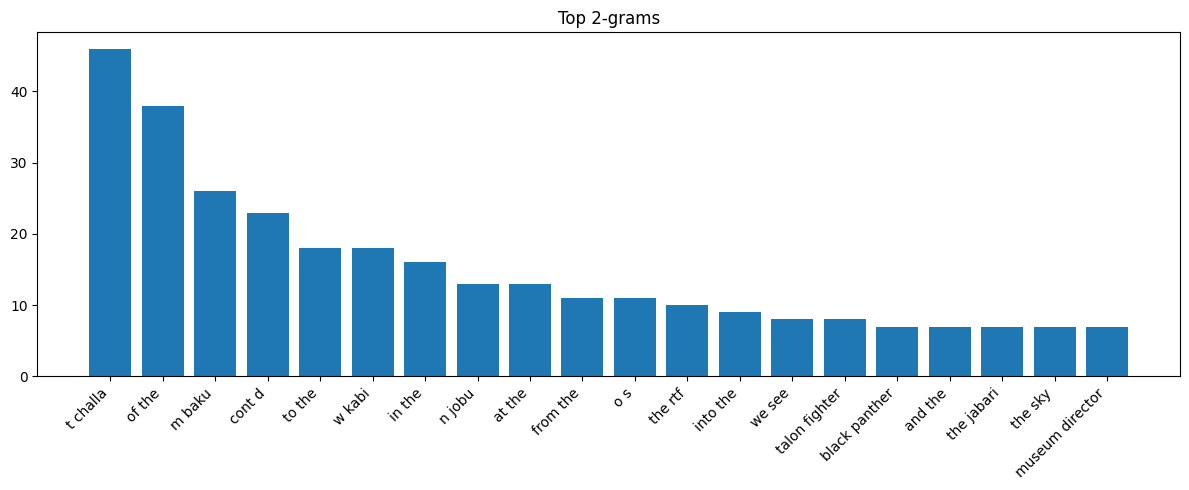

In [ ]:
#N-GRAM ANALYSIS
def plot_ngrams(sentences, n=2, top_k=20):

    tokens = []

    for sentence in sentences:

        tokens.extend(
            word_tokenize(sentence.lower())
        )

    ngram_counts = Counter(
        ngrams(tokens, n)
    ).most_common(top_k)

    if not ngram_counts:
        print("No n-grams found.")
        return

    labels = [
        " ".join(words)
        for words, _ in ngram_counts
    ]

    values = [
        count
        for _, count in ngram_counts
    ]

    plt.figure(figsize=(12,5))

    plt.bar(labels, values)

    plt.xticks(rotation=45, ha="right")

    plt.title(f"Top {n}-grams")

    plt.tight_layout()

    plt.show()

plot_ngrams(myth_sentences)

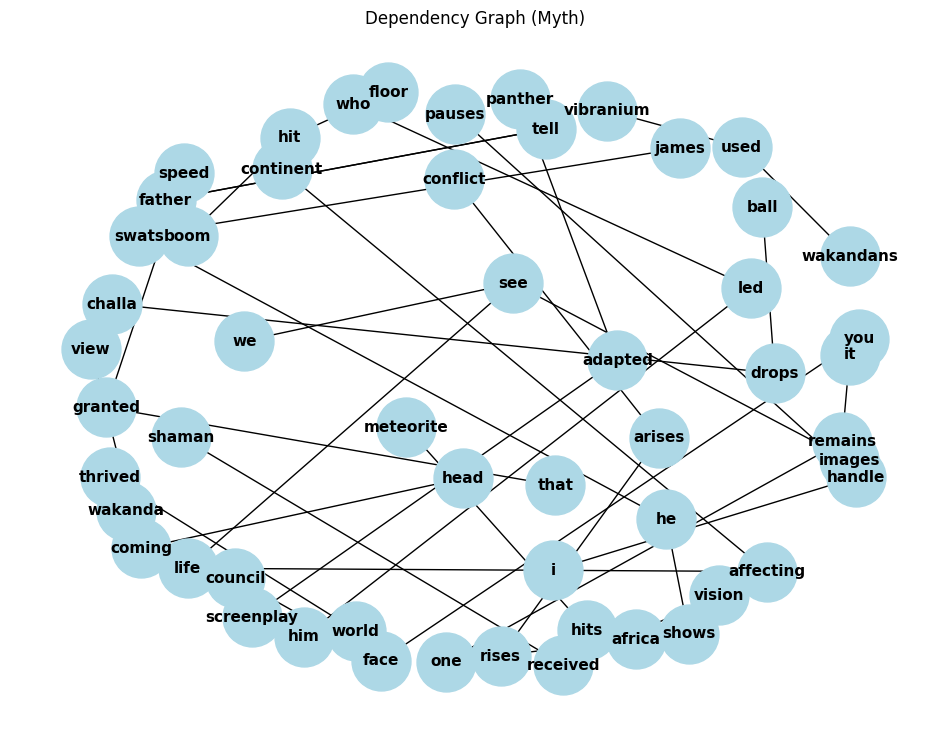

In [ ]:
#DEPENDENCY GRAPH

def draw_dependency_graph(
    relationships,
    title,
    max_edges=50
):

    graph = nx.DiGraph()

    for subject, verb, objects in relationships[:max_edges]:

        for obj in objects:

            graph.add_edge(subject, verb)

            graph.add_edge(verb, obj)

    plt.figure(figsize=(12,9))

    positions = nx.spring_layout(
        graph,
        seed=42,
        k=1.2
    )

    nx.draw_networkx_nodes(
        graph,
        positions,
        node_size=1800,
        node_color="lightblue"
    )

    nx.draw_networkx_edges(
        graph,
        positions,
        arrows=True
    )

    nx.draw_networkx_labels(
        graph,
        positions,
        font_size=11,
        font_weight="bold"
    )

    plt.title(title)

    plt.axis("off")

    plt.show()

draw_dependency_graph(
    myth_dependencies,
    "Dependency Graph (Myth)"
)

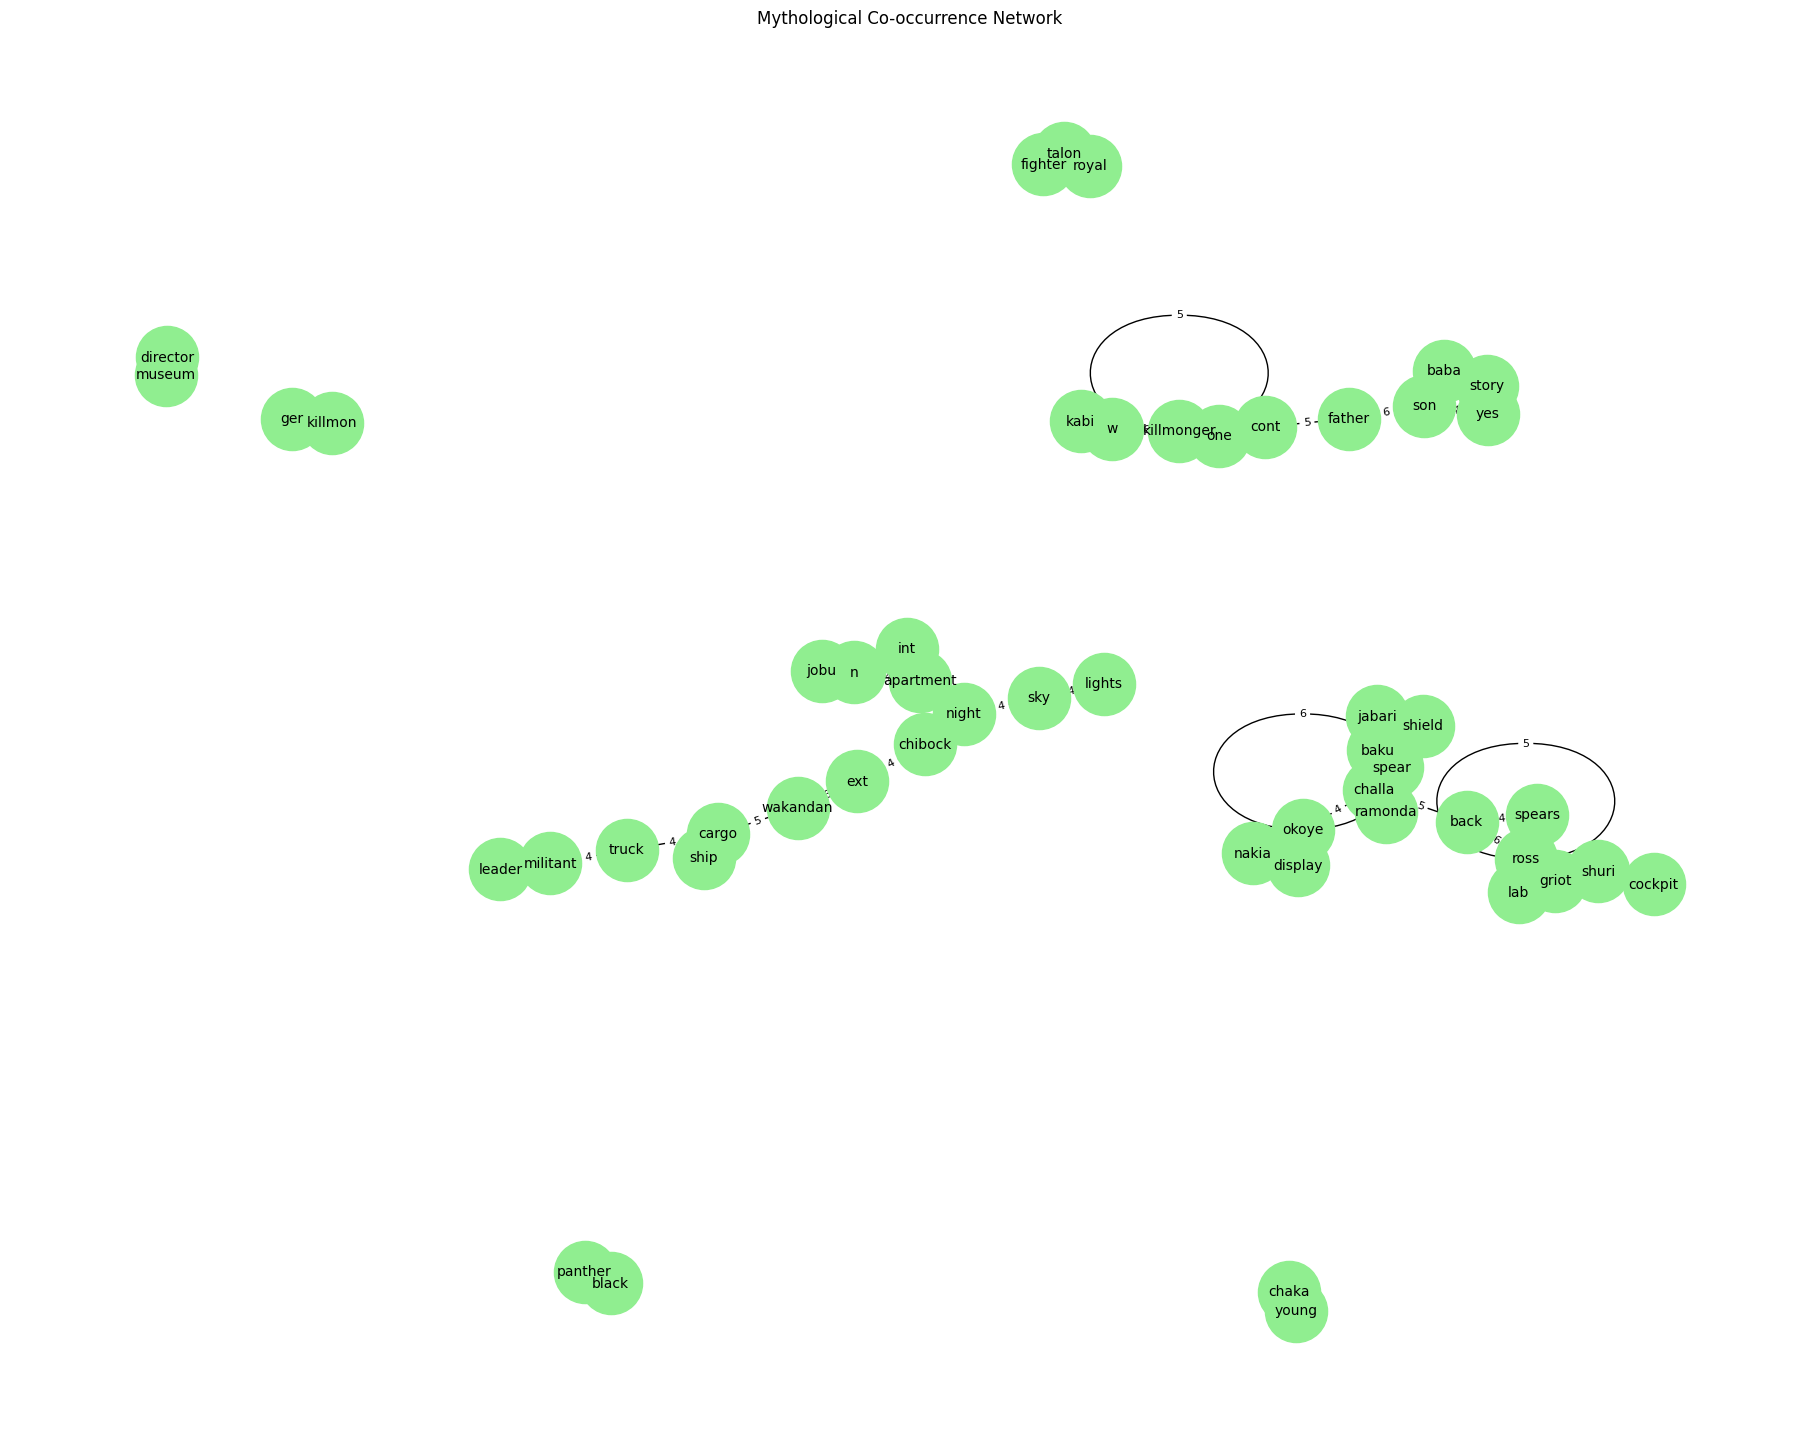

In [ ]:
#Co-occurence Graph
def draw_cooccurrence_graph(
    sentences,
    title,
    window_size=3
):

    graph = nx.Graph()

    cooccurrences = Counter()

    for sentence in sentences:

        tokens = [

            word.lower()

            for word in sentence.split()

            if word.lower() not in common_words

        ]

        for i, word in enumerate(tokens):

            window = tokens[
                i+1 :
                i+1+window_size
            ]

            for neighbour in window:

                pair = tuple(
                    sorted(
                        [word, neighbour]
                    )
                )

                cooccurrences[pair] += 1

    for (word1, word2), weight in cooccurrences.most_common(50):

        graph.add_edge(
            word1,
            word2,
            weight=weight
        )

    plt.figure(figsize=(18,14))

    positions = nx.spring_layout(
        graph,
        seed=42
    )

    nx.draw(
        graph,
        positions,
        with_labels=True,
        node_size=2000,
        node_color="lightgreen",
        font_size=10
    )

    edge_labels = nx.get_edge_attributes(
        graph,
        "weight"
    )

    nx.draw_networkx_edge_labels(
        graph,
        positions,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title(title)

    plt.show()

draw_cooccurrence_graph(
    myth_sentences,
    "Mythological Co-occurrence Network"
)